In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/stefannezgoda/tallinn-restaurants-2026/restaraunts_tallinn.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/stefannezgoda/tallinn-restaurants-2026/restaraunts_tallinn.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Restaurant      97 non-null     object 
 1   URL             94 non-null     object 
 2   Address         97 non-null     object 
 3   Cuisine         97 non-null     object 
 4   Price_category  97 non-null     object 
 5   Atmosphere      97 non-null     float64
 6   Food            97 non-null     float64
 7   Service         97 non-null     float64
 8   Weighted_score  97 non-null     float64
 9   Latitude        97 non-null     float64
 10  Longitude       97 non-null     float64
dtypes: float64(6), object(5)
memory usage: 8.5+ KB


In [4]:
df.head()

,Restaurant,URL,Address,Cuisine,Price_category,Atmosphere,Food,Service,Weighted_score,Latitude,Longitude
0,Al Mare Grill,http://www.almarefood.ee/grill/,Mõisa tn 4,american,mid-range,3.5,3.0,3.1,3.12,59.427152,24.655658
1,Allee,https://www.alleerestoran.ee/,Kanuti 2,international,mid-range,4.0,4.1,3.9,4.04,59.440128,24.751131
2,Argentiina Lootsi,https://argentiina.ee/,Lootsi 8,argentinean,expensive,3.3,4.3,3.6,3.96,59.440838,24.765225
3,Argentiina Pärnu mnt,https://argentiina.ee/,Pärnu mnt 37,argentinean,expensive,4.1,4.5,4.2,4.36,59.429272,24.743789
4,Charlies Corner,https://charliescorner.ee/,Juhkentali 28,international,mid-range,3.9,3.9,3.9,3.90,59.427606,24.764699


In [5]:
df.describe()

,Atmosphere,Food,Service,Weighted_score,Latitude,Longitude
count,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000
mean,4.209278,4.279381,4.169072,4.243299,59.416731,24.788735
std,0.487144,0.425230,0.398006,0.392446,0.150107,0.283567
min,2.400000,1.600000,2.600000,2.080000,58.389640,24.572022
25%,4.000000,4.100000,4.000000,4.080000,59.435863,24.743789
50%,4.300000,4.300000,4.200000,4.280000,59.437705,24.747650
75%,4.600000,4.500000,4.400000,4.500000,59.439840,24.758630
max,4.900000,4.900000,4.800000,4.780000,59.493650,26.717700


In [6]:
df.isnull().sum()

Restaurant        0
URL               3
Address           0
Cuisine           0
Price_category    0
Atmosphere        0
Food              0
Service           0
Weighted_score    0
Latitude          0
Longitude         0
dtype: int64

In [7]:
df["URL"]=df["URL"].fillna("No Link")

In [8]:
df["Score_Diff"]=df["Food"]-df["Service"]

In [9]:
df["Avg_Quality"]=(df["Food"]+df["Service"]+df["Atmosphere"])/3

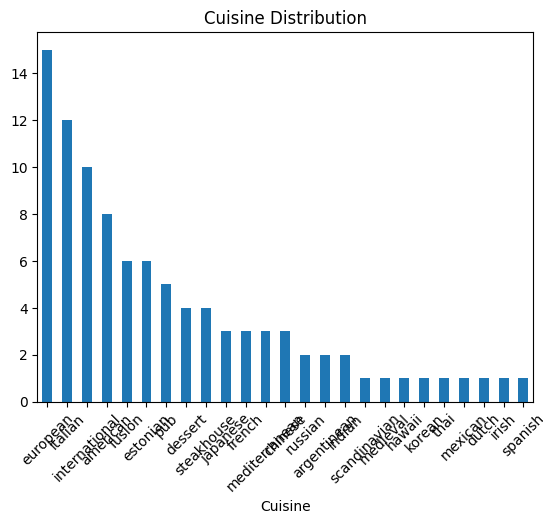

In [10]:
df["Cuisine"].value_counts().plot(kind="bar")
plt.title("Cuisine Distribution")
plt.xticks(rotation=45)
plt.show()

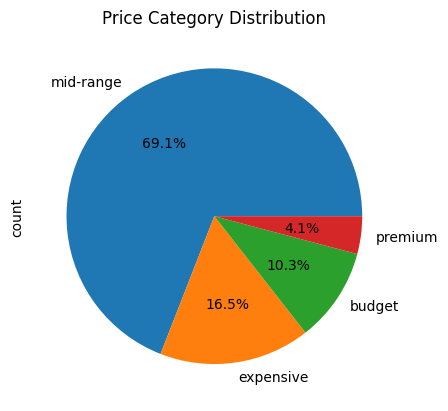

In [11]:
df["Price_category"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Price Category Distribution")
plt.show()

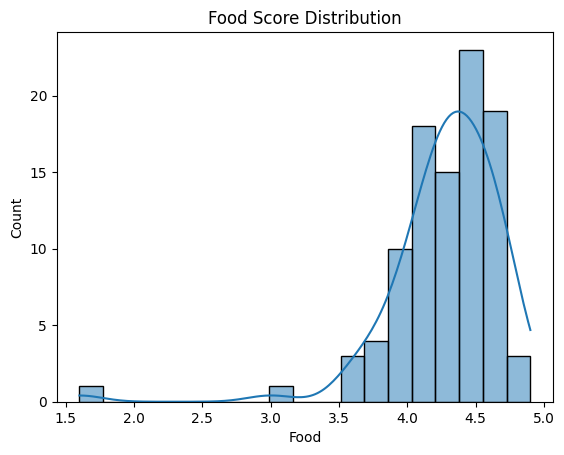

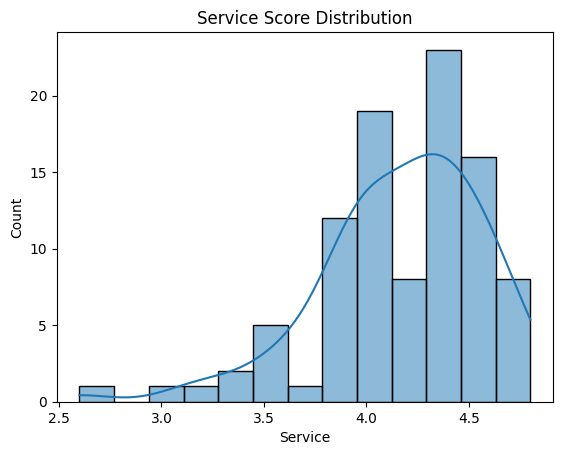

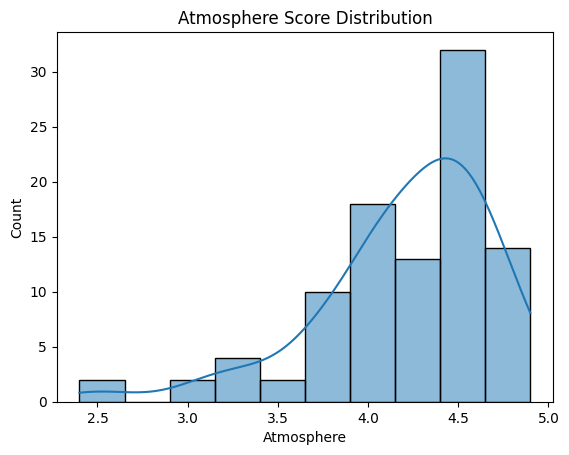

In [12]:
sns.histplot(df["Food"], kde=True)
plt.title("Food Score Distribution")
plt.show()

sns.histplot(df["Service"], kde=True)
plt.title("Service Score Distribution")
plt.show()

sns.histplot(df["Atmosphere"], kde=True)
plt.title("Atmosphere Score Distribution")
plt.show()

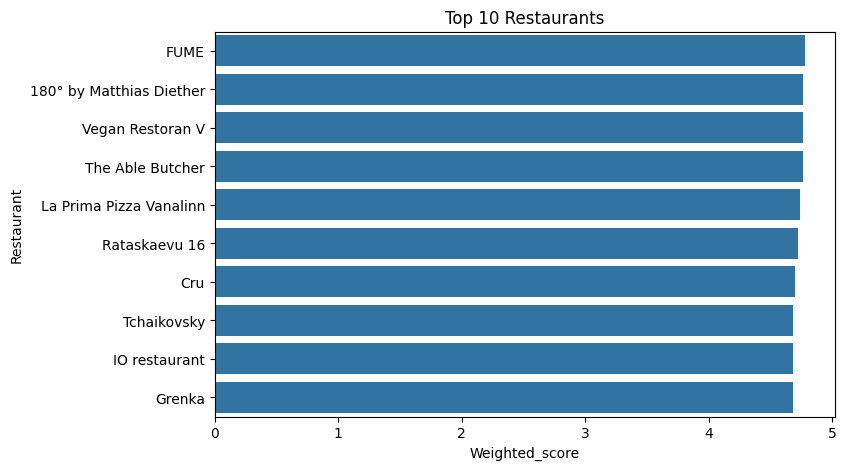

In [13]:
top10=df.sort_values(by="Weighted_score", ascending=False).head(10)
plt.figure(figsize=(8,5))
sns.barplot(x="Weighted_score", y="Restaurant", data=top10)
plt.title("Top 10 Restaurants")
plt.show()

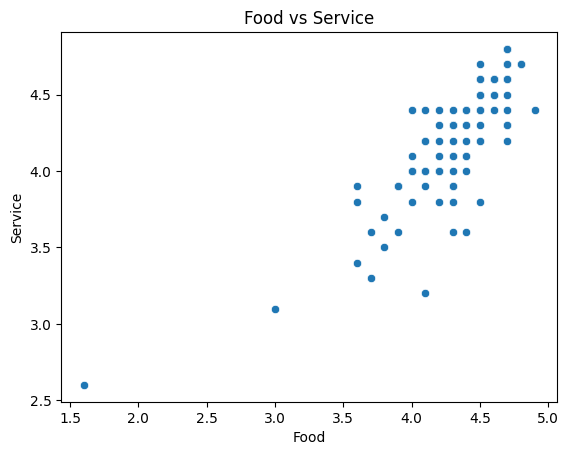

In [14]:
sns.scatterplot(x="Food", y="Service", data=df)
plt.title("Food vs Service")
plt.show()

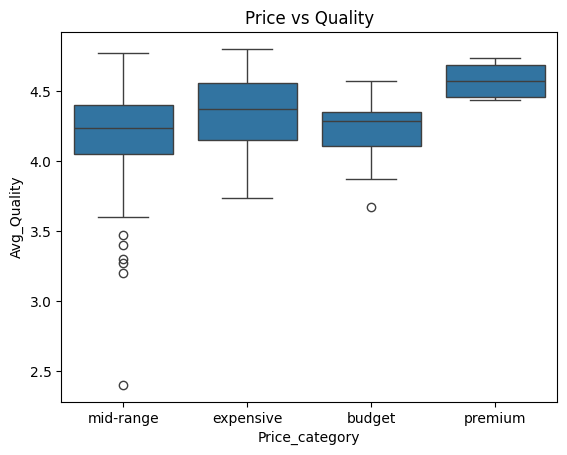

In [15]:
sns.boxplot(x="Price_category", y="Avg_Quality", data=df)
plt.title("Price vs Quality")
plt.show()

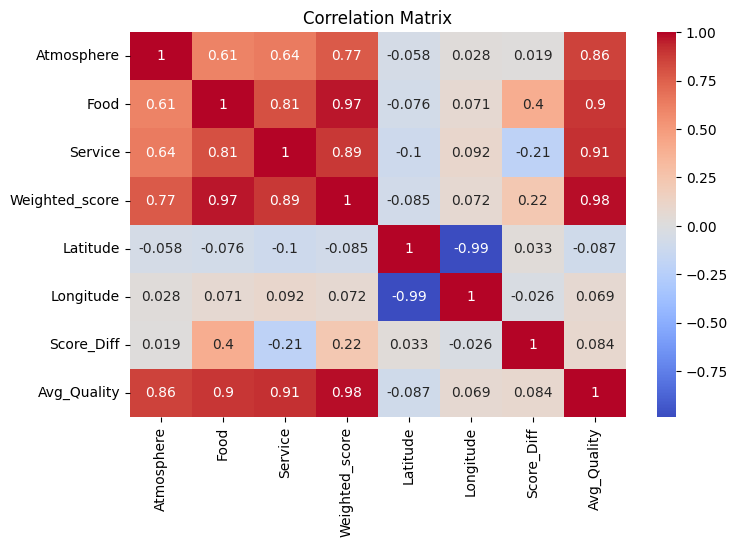

In [16]:
numeric_cols=df.select_dtypes(include=np.number)
plt.figure(figsize=(8,5))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

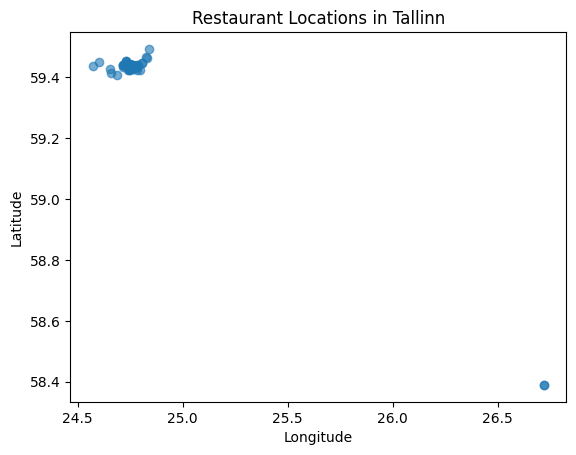

In [17]:
plt.scatter(df["Longitude"], df["Latitude"], alpha=0.6)
plt.title("Restaurant Locations in Tallinn")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

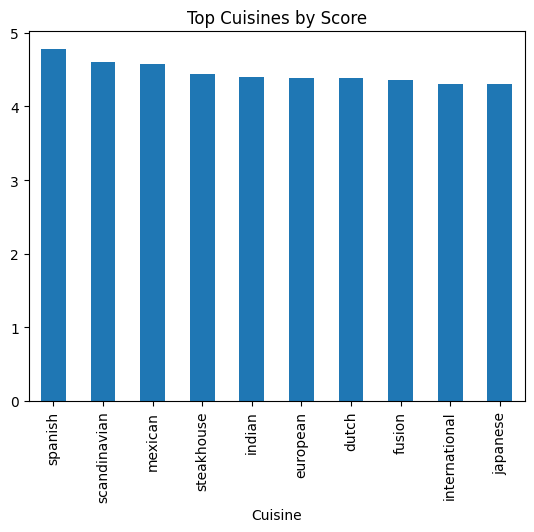

In [18]:
df.groupby("Cuisine")["Weighted_score"].mean().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top Cuisines by Score")
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

df_ml=df.copy()

le=LabelEncoder()
for col in ["Cuisine", "Price_category"]:
    df_ml[col]=le.fit_transform(df_ml[col])

X=df_ml.drop(["Restaurant","URL","Address","Weighted_score"], axis=1)
y=df_ml["Weighted_score"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

model=RandomForestRegressor()
model.fit(X_train, y_train)

print("Model Score:", model.score(X_test, y_test))

Model Score: 0.9124498697466402
